In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

Modelagem

In [2]:
dataset = pd.read_csv('C:/Users/kened/OneDrive/Desktop/Estudos/Lean/data/processed/virus_processed.csv')
dataset

,virus_id,family,genus,genome_type,strand,enveloped,transmission,mortality,r0,host,target
0,1,Unknown,Betacoronavirus,RNA,ssRNA(+),True,airborne,2.00,2.50,human,0
1,2,Orthomyxoviridae,Unknown,RNA,ssRNA(-),True,airborne,0.10,1.30,human,0
2,3,Retroviridae,Lentivirus,RNA,ssRNA-RT,True,bodily fluids,80.00,2.00,human,1
3,4,Filoviridae,Ebolavirus,RNA,ssRNA(-),True,airborne,5.91,1.80,human,0
4,5,Unknown,Flavivirus,RNA,ssRNA(+),True,vector,0.01,3.00,human,0
...,...,...,...,...,...,...,...,...,...,...,...
65,66,Unknown,Unknown,Unknown,Unknown,Unknown,airborne,3.92,1.32,both,0
66,67,Unknown,Unknown,Unknown,Unknown,Unknown,contact,1.20,1.21,both,0
67,68,Unknown,Unknown,Unknown,Unknown,Unknown,bodily fluids,3.41,1.03,both,0
68,69,Unknown,Unknown,Unknown,Unknown,Unknown,airborne,4.29,1.19,animal,0


In [3]:
X = dataset.drop(columns=['target', 'virus_id'])
y = dataset['target']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Distribuição de y:', y.value_counts().to_dict())

X shape: (70, 9)
y shape: (70,)
Distribuição de y: {0: 68, 1: 2}


In [5]:
X_encoded = pd.get_dummies(X, dtype=int)
print('Shape após encoding:', X_encoded.shape)
X_encoded.head()

Shape após encoding: (70, 63)


,mortality,r0,family_Adenoviridae,family_Arenaviridae,family_Caliciviridae,family_Coronaviridae,family_Filoviridae,family_Flaviviridae,family_Hantaviridae,family_Hepadnaviridae,...,enveloped_Unknown,transmission_airborne,transmission_animal bite,transmission_bodily fluids,transmission_contact,transmission_vector,host_Unknown,host_animal,host_both,host_human
0,2.00,2.5,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
1,0.10,1.3,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
2,80.00,2.0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
3,5.91,1.8,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
4,0.01,3.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, stratify=y, random_state=42)

print('Treino:', X_train.shape, '| Distribuição:', y_train.value_counts().to_dict())
print('Teste:', X_test.shape, '| Distribuição:', y_test.value_counts().to_dict())

Treino: (49, 63) | Distribuição: {0: 48, 1: 1}
Teste: (21, 63) | Distribuição: {0: 20, 1: 1}


In [12]:
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
y_pred = modelo_lr.predict(X_test)

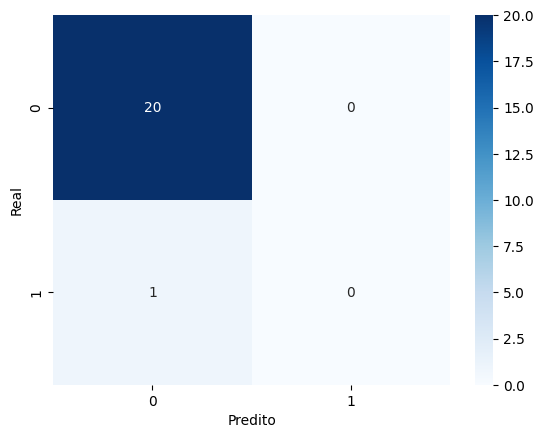

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       0.00      0.00      0.00         1

    accuracy                           0.95        21
   macro avg       0.48      0.50      0.49        21
weighted avg       0.91      0.95      0.93        21



c:\Users\kened\OneDrive\Desktop\Estudos\RAG\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kened\OneDrive\Desktop\Estudos\RAG\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kened\OneDrive\Desktop\Estudos\RAG\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

In [15]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

print(classification_report(y_test, y_pred))